In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import sklearn
import catboost

print("Python:", sys.executable)
print("Рабочая папка:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("catboost:", catboost.__version__)

Python: C:\venvs\shiftcs\Scripts\python.exe
Рабочая папка: C:\Users\Viktor\Documents\GitHub\shift-credit-scoring-2026
pandas: 3.0.3
numpy: 2.5.1
scikit-learn: 1.9.0
catboost: 1.2.10


# Кредитный скоринг: прогноз серьёзной просрочки

## Цель работы

Необходимо предсказать вероятность серьёзной просрочки заёмщика в течение 90 дней после выдачи займа.

**Тип задачи:** бинарная классификация.  
**Целевая переменная:** `target`.  
**Метрика соревнования:** ROC-AUC.

В решении используются данные заявки, транзакционная история клиента, внешняя кредитная история и сведения о предыдущих займах.

In [3]:
# Основные настройки проекта

RANDOM_STATE = 42
TARGET_COLUMN = "target"
APPLICATION_ID_COLUMN = "application_id"
CLIENT_ID_COLUMN = "client_id"

DATA_DIR = Path("data/raw")
OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "train.csv",
    "test.csv",
    "transactions.csv",
    "bureau.csv",
    "previous_loans.csv",
    "sample_submission.csv",
]

missing_files = [
    filename
    for filename in required_files
    if not (DATA_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        f"В папке {DATA_DIR.resolve()} отсутствуют файлы: {missing_files}"
    )

print("Папка с данными:", DATA_DIR.resolve())
print("Все необходимые файлы найдены.")

Папка с данными: C:\Users\Viktor\Documents\GitHub\shift-credit-scoring-2026\data\raw
Все необходимые файлы найдены.


In [4]:
train = pd.read_csv(
    DATA_DIR / "train.csv",
    parse_dates=["application_date"],
    low_memory=False,
)

test = pd.read_csv(
    DATA_DIR / "test.csv",
    parse_dates=["application_date"],
    low_memory=False,
)

transactions = pd.read_csv(
    DATA_DIR / "transactions.csv",
    parse_dates=["transaction_date"],
    low_memory=False,
)

bureau = pd.read_csv(
    DATA_DIR / "bureau.csv",
    low_memory=False,
)

previous_loans = pd.read_csv(
    DATA_DIR / "previous_loans.csv",
    low_memory=False,
)

sample_submission = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    low_memory=False,
)

print("Данные успешно загружены.")

Данные успешно загружены.


In [5]:
datasets_summary = pd.DataFrame(
    {
        "dataset": [
            "train",
            "test",
            "transactions",
            "bureau",
            "previous_loans",
            "sample_submission",
        ],
        "rows": [
            len(train),
            len(test),
            len(transactions),
            len(bureau),
            len(previous_loans),
            len(sample_submission),
        ],
        "columns": [
            train.shape[1],
            test.shape[1],
            transactions.shape[1],
            bureau.shape[1],
            previous_loans.shape[1],
            sample_submission.shape[1],
        ],
    }
)

datasets_summary

,dataset,rows,columns
0,train,6488,25
1,test,2520,24
2,transactions,353300,6
3,bureau,24689,8
4,previous_loans,12762,7
5,sample_submission,2520,2


In [6]:
audit_summary = pd.Series(
    {
        "Строк в train": len(train),
        "Строк в test": len(test),
        "Уникальных application_id в train": train[APPLICATION_ID_COLUMN].nunique(),
        "Уникальных application_id в test": test[APPLICATION_ID_COLUMN].nunique(),
        "Полных дубликатов в train": train.duplicated().sum(),
        "Дубликатов application_id в train": (
            train[APPLICATION_ID_COLUMN].duplicated().sum()
        ),
        "Пересечение application_id train/test": len(
            set(train[APPLICATION_ID_COLUMN])
            & set(test[APPLICATION_ID_COLUMN])
        ),
        "Пересечение client_id train/test": len(
            set(train[CLIENT_ID_COLUMN])
            & set(test[CLIENT_ID_COLUMN])
        ),
        "Минимальная дата train": train["application_date"].min(),
        "Максимальная дата train": train["application_date"].max(),
        "Минимальная дата test": test["application_date"].min(),
        "Максимальная дата test": test["application_date"].max(),
    },
    name="Значение",
).to_frame()

audit_summary

,Значение
Строк в train,6488
Строк в test,2520
Уникальных application_id в train,6480
Уникальных application_id в test,2520
Полных дубликатов в train,8
Дубликатов application_id в train,8
Пересечение application_id train/test,0
Пересечение client_id train/test,0
Минимальная дата train,2025-01-01 00:00:00
Максимальная дата train,2025-12-31 00:00:00


,Количество,Доля
target,,
0,4268,0.65783
1,2220,0.34217


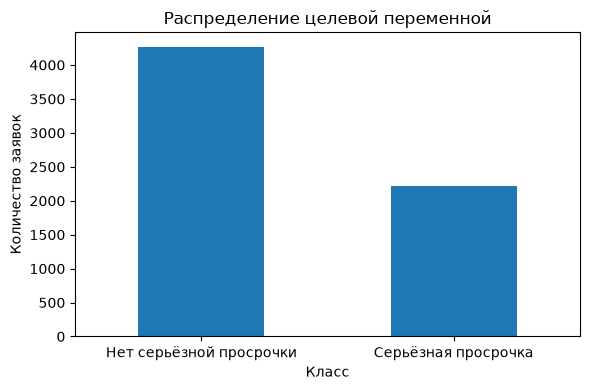

In [7]:
import matplotlib.pyplot as plt

target_distribution = (
    train[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COLUMN)
    .to_frame("Количество")
)

target_distribution["Доля"] = (
    target_distribution["Количество"] / len(train)
)

display(target_distribution)

fig, ax = plt.subplots(figsize=(6, 4))

target_distribution["Количество"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Распределение целевой переменной")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество заявок")
ax.set_xticklabels(["Нет серьёзной просрочки", "Серьёзная просрочка"], rotation=0)

plt.tight_layout()
plt.show()

In [8]:
feature_columns = [
    column
    for column in train.columns
    if column != TARGET_COLUMN
]

missing_comparison = pd.DataFrame(
    {
        "Признак": feature_columns,
        "Пропуски train, %": [
            train[column].isna().mean() * 100
            for column in feature_columns
        ],
        "Пропуски test, %": [
            test[column].isna().mean() * 100
            for column in feature_columns
        ],
        "Уникальных train": [
            train[column].nunique(dropna=True)
            for column in feature_columns
        ],
        "Уникальных test": [
            test[column].nunique(dropna=True)
            for column in feature_columns
        ],
    }
)

missing_comparison["Разница пропусков, п.п."] = (
    missing_comparison["Пропуски test, %"]
    - missing_comparison["Пропуски train, %"]
).abs()

missing_comparison = missing_comparison.sort_values(
    by=["Пропуски test, %", "Разница пропусков, п.п."],
    ascending=False,
).reset_index(drop=True)

missing_comparison.head(15).round(2)

,Признак,"Пропуски train, %","Пропуски test, %",Уникальных train,Уникальных test,"Разница пропусков, п.п."
0,internal_decision_code,21.18,100.00,6,0,78.82
1,post_loan_collection_score,23.71,100.00,4724,0,76.29
2,days_until_first_overdue,28.61,100.00,156,0,71.39
3,monthly_income,6.80,9.37,5514,2084,2.57
4,region,8.42,9.37,7,7,0.95
5,hash_id,6.43,9.09,6064,2291,2.66
6,region_coefficient_extended,7.11,8.17,2,2,1.07
7,channel,8.89,8.13,5,5,0.76
8,interest_rate,5.78,8.06,2661,1596,2.28
9,incoming_amount,6.67,8.02,5520,2111,1.34


In [9]:
fully_missing_in_test = [
    column
    for column in test.columns
    if test[column].isna().all()
]

print("Полностью отсутствуют в test:")
for column in fully_missing_in_test:
    print(f"- {column}")

Полностью отсутствуют в test:
- post_loan_collection_score
- internal_decision_code
- days_until_first_overdue


## Первичные выводы EDA

- Обучающая выборка содержит 6 488 строк, тестовая — 2 520 строк.
- Доля заявок с серьёзной просрочкой составляет 34,2%. Дисбаланс классов умеренный, поэтому на текущем этапе искусственное балансирование не применяется.
- Метрика ROC-AUC оценивает качество ранжирования вероятностей и не требует выбора фиксированного порога классификации.
- В тестовой выборке полностью отсутствуют признаки `post_loan_collection_score`, `internal_decision_code` и `days_until_first_overdue`.
- Эти признаки исключаются из моделирования, поскольку недоступны при формировании прогноза и могут привести к завышенной локальной оценке качества.

In [10]:
duplicate_rows_count = int(train.duplicated().sum())
duplicate_application_ids_count = int(
    train[APPLICATION_ID_COLUMN].duplicated().sum()
)

print("Полных дубликатов:", duplicate_rows_count)
print(
    "Повторяющихся application_id:",
    duplicate_application_ids_count,
)

# Все повторяющиеся application_id соответствуют полным дубликатам строк.
assert duplicate_rows_count == duplicate_application_ids_count

train_clean = (
    train
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Размер train до очистки:", train.shape)
print("Размер train после очистки:", train_clean.shape)

assert train_clean[APPLICATION_ID_COLUMN].is_unique

Полных дубликатов: 8
Повторяющихся application_id: 8
Размер train до очистки: (6488, 25)
Размер train после очистки: (6480, 25)


In [11]:
UNAVAILABLE_IN_TEST_COLUMNS = fully_missing_in_test

IDENTIFIER_COLUMNS = [
    APPLICATION_ID_COLUMN,
    CLIENT_ID_COLUMN,
]

MODEL_EXCLUDED_COLUMNS = [
    TARGET_COLUMN,
    *IDENTIFIER_COLUMNS,
    *UNAVAILABLE_IN_TEST_COLUMNS,
]

base_feature_columns = [
    column
    for column in train_clean.columns
    if column not in MODEL_EXCLUDED_COLUMNS
]

print("Недоступные в test признаки:", UNAVAILABLE_IN_TEST_COLUMNS)
print("Идентификаторы:", IDENTIFIER_COLUMNS)
print("Количество базовых признаков модели:", len(base_feature_columns))
print(base_feature_columns)

Недоступные в test признаки: ['post_loan_collection_score', 'internal_decision_code', 'days_until_first_overdue']
Идентификаторы: ['application_id', 'client_id']
Количество базовых признаков модели: 19
['employment_type', 'hash_id', 'region_coefficient_extended', 'age', 'incoming_amount', 'monthly_income', 'application_date', 'education', 'requested_product', 'channel', 'loan_amount', 'marketing_segment', 'region_coefficient', 'region', 'interest_rate', 'months_at_job', 'dependents', 'loan_term_months', 'siberia_northern_score']


## Связи таблиц и качество вспомогательных данных

Проверим покрытие заявок транзакционной и кредитной историей, корректность ключей соединения, наличие дубликатов и отсутствие транзакций после даты подачи заявки.

In [12]:
applications_reference = pd.concat(
    [
        train_clean[
            [APPLICATION_ID_COLUMN, CLIENT_ID_COLUMN, "application_date"]
        ],
        test[
            [APPLICATION_ID_COLUMN, CLIENT_ID_COLUMN, "application_date"]
        ],
    ],
    ignore_index=True,
)

assert applications_reference[APPLICATION_ID_COLUMN].is_unique
assert applications_reference[CLIENT_ID_COLUMN].is_unique

transactions_audit = transactions.merge(
    applications_reference,
    on=[APPLICATION_ID_COLUMN, CLIENT_ID_COLUMN],
    how="left",
    validate="many_to_one",
    indicator=True,
)

transactions_audit["days_before_application"] = (
    transactions_audit["application_date"]
    - transactions_audit["transaction_date"]
).dt.days

relation_audit = pd.Series(
    {
        "Всего заявок train + test": len(applications_reference),
        "Заявок с транзакциями": applications_reference[
            APPLICATION_ID_COLUMN
        ].isin(transactions[APPLICATION_ID_COLUMN]).sum(),
        "Клиентов с данными bureau": applications_reference[
            CLIENT_ID_COLUMN
        ].isin(bureau[CLIENT_ID_COLUMN]).sum(),
        "Клиентов с previous loans": applications_reference[
            CLIENT_ID_COLUMN
        ].isin(previous_loans[CLIENT_ID_COLUMN]).sum(),
        "Не связанных с заявками транзакций": (
            transactions_audit["_merge"] != "both"
        ).sum(),
        "Транзакций после даты заявки": (
            transactions_audit["days_before_application"] < 0
        ).sum(),
        "Полных дубликатов transactions": transactions.duplicated().sum(),
        "Полных дубликатов bureau": bureau.duplicated().sum(),
        "Полных дубликатов previous_loans": (
            previous_loans.duplicated().sum()
        ),
    },
    name="Значение",
).to_frame()

relation_audit

,Значение
Всего заявок train + test,9000
Заявок с транзакциями,9000
Клиентов с данными bureau,8542
Клиентов с previous loans,6885
Не связанных с заявками транзакций,0
Транзакций после даты заявки,0
Полных дубликатов transactions,10
Полных дубликатов bureau,6
Полных дубликатов previous_loans,4


In [13]:
transactions_clean = (
    transactions
    .drop_duplicates()
    .reset_index(drop=True)
)

bureau_clean = (
    bureau
    .drop_duplicates()
    .reset_index(drop=True)
)

previous_loans_clean = (
    previous_loans
    .drop_duplicates()
    .reset_index(drop=True)
)

cleaning_summary = pd.DataFrame(
    {
        "Таблица": [
            "transactions",
            "bureau",
            "previous_loans",
        ],
        "Строк до очистки": [
            len(transactions),
            len(bureau),
            len(previous_loans),
        ],
        "Строк после очистки": [
            len(transactions_clean),
            len(bureau_clean),
            len(previous_loans_clean),
        ],
    }
)

cleaning_summary["Удалено дубликатов"] = (
    cleaning_summary["Строк до очистки"]
    - cleaning_summary["Строк после очистки"]
)

cleaning_summary

,Таблица,Строк до очистки,Строк после очистки,Удалено дубликатов
0,transactions,353300,353290,10
1,bureau,24689,24683,6
2,previous_loans,12762,12758,4


### Выводы по связям таблиц

- Транзакционная история присутствует для всех заявок.
- Внешняя кредитная история и сведения о прошлых займах доступны не для каждого клиента. Отсутствие таких записей само по себе может быть полезным признаком.
- Все транзакции с известной датой заявки совершены до подачи заявки, поэтому временной утечки не обнаружено.
- Из вспомогательных таблиц удалены полные дубликаты, чтобы они не искажали суммы, средние значения и количества записей.
- Таблица `transactions` связывается с заявкой по `application_id`, а `bureau` и `previous_loans` — с клиентом по `client_id`.

## Создание признаков из транзакционной истории

Транзакции агрегируются до уровня заявки. Формируются признаки общего денежного оборота, поступлений и расходов, активности клиента, риска торговых точек, категорий операций и поведения за различные временные интервалы до даты заявки.

In [14]:
transactions_enriched = transactions_clean.merge(
    applications_reference,
    on=[APPLICATION_ID_COLUMN, CLIENT_ID_COLUMN],
    how="left",
    validate="many_to_one",
)

transactions_enriched["days_before_application"] = (
    transactions_enriched["application_date"]
    - transactions_enriched["transaction_date"]
).dt.days

transactions_enriched["transaction_category_clean"] = (
    transactions_enriched["transaction_category"]
    .fillna("missing")
    .astype(str)
    .str.lower()
)

# Положительные суммы — поступления, отрицательные — расходы.
transactions_enriched["inflow_amount"] = (
    transactions_enriched["amount"]
    .where(transactions_enriched["amount"] > 0)
)

transactions_enriched["outflow_amount"] = (
    -transactions_enriched["amount"]
    .where(transactions_enriched["amount"] < 0)
)

transactions_enriched["is_inflow"] = (
    transactions_enriched["amount"] > 0
).astype("int8")

transactions_enriched["is_outflow"] = (
    transactions_enriched["amount"] < 0
).astype("int8")

transactions_enriched["is_high_risk_merchant"] = (
    transactions_enriched["merchant_risk_level"] >= 4
).astype("int8")

transactions_enriched["amount_missing"] = (
    transactions_enriched["amount"].isna()
).astype("int8")

transactions_enriched["risk_missing"] = (
    transactions_enriched["merchant_risk_level"].isna()
).astype("int8")

transactions_enriched["date_missing"] = (
    transactions_enriched["transaction_date"].isna()
).astype("int8")

known_transaction_dates = (
    transactions_enriched["days_before_application"].notna()
)

transactions_after_application = (
    transactions_enriched.loc[
        known_transaction_dates,
        "days_before_application",
    ] < 0
).sum()

assert transactions_after_application == 0

print("Подготовлено транзакций:", len(transactions_enriched))
print(
    "Уникальных заявок:",
    transactions_enriched[APPLICATION_ID_COLUMN].nunique(),
)
print(
    "Транзакций после даты заявки:",
    transactions_after_application,
)

Подготовлено транзакций: 353290
Уникальных заявок: 9000
Транзакций после даты заявки: 0


In [15]:
transaction_base_features = (
    transactions_enriched
    .groupby(APPLICATION_ID_COLUMN, as_index=False)
    .agg(
        tx_count=(APPLICATION_ID_COLUMN, "size"),
        tx_amount_observed_count=("amount", "count"),
        tx_amount_sum=("amount", "sum"),
        tx_amount_mean=("amount", "mean"),
        tx_amount_median=("amount", "median"),
        tx_amount_std=("amount", "std"),
        tx_amount_min=("amount", "min"),
        tx_amount_max=("amount", "max"),

        tx_inflow_count=("is_inflow", "sum"),
        tx_inflow_sum=("inflow_amount", "sum"),
        tx_inflow_mean=("inflow_amount", "mean"),

        tx_outflow_count=("is_outflow", "sum"),
        tx_outflow_sum=("outflow_amount", "sum"),
        tx_outflow_mean=("outflow_amount", "mean"),

        tx_risk_mean=("merchant_risk_level", "mean"),
        tx_risk_max=("merchant_risk_level", "max"),
        tx_risk_std=("merchant_risk_level", "std"),
        tx_high_risk_count=("is_high_risk_merchant", "sum"),

        tx_unique_categories=(
            "transaction_category_clean",
            "nunique",
        ),
        tx_unique_transaction_days=(
            "transaction_date",
            "nunique",
        ),

        tx_days_before_min=("days_before_application", "min"),
        tx_days_before_max=("days_before_application", "max"),

        tx_amount_missing_count=("amount_missing", "sum"),
        tx_risk_missing_count=("risk_missing", "sum"),
        tx_date_missing_count=("date_missing", "sum"),
    )
)

transaction_base_features["tx_inflow_share"] = (
    transaction_base_features["tx_inflow_count"]
    / transaction_base_features[
        "tx_amount_observed_count"
    ].clip(lower=1)
)

transaction_base_features["tx_outflow_share"] = (
    transaction_base_features["tx_outflow_count"]
    / transaction_base_features[
        "tx_amount_observed_count"
    ].clip(lower=1)
)

observed_risk_count = (
    transaction_base_features["tx_count"]
    - transaction_base_features["tx_risk_missing_count"]
).clip(lower=1)

transaction_base_features["tx_high_risk_share"] = (
    transaction_base_features["tx_high_risk_count"]
    / observed_risk_count
)

for prefix in ["amount", "risk", "date"]:
    transaction_base_features[
        f"tx_{prefix}_missing_share"
    ] = (
        transaction_base_features[
            f"tx_{prefix}_missing_count"
        ]
        / transaction_base_features["tx_count"]
    )

transaction_base_features["tx_turnover"] = (
    transaction_base_features["tx_inflow_sum"]
    + transaction_base_features["tx_outflow_sum"]
)

transaction_base_features["tx_net_to_turnover"] = (
    transaction_base_features["tx_amount_sum"]
    / (
        transaction_base_features["tx_turnover"]
        + 1e-6
    )
)

transaction_base_features["tx_outflow_to_inflow"] = (
    transaction_base_features["tx_outflow_sum"]
    / (
        transaction_base_features["tx_inflow_sum"]
        + 1e-6
    )
)

transaction_base_features["tx_history_span_days"] = (
    transaction_base_features["tx_days_before_max"]
    - transaction_base_features["tx_days_before_min"]
)

transaction_category_counts = (
    pd.crosstab(
        transactions_enriched[APPLICATION_ID_COLUMN],
        transactions_enriched["transaction_category_clean"],
    )
    .add_prefix("tx_category_count__")
    .reset_index()
)

transaction_category_outflows = (
    transactions_enriched
    .pivot_table(
        index=APPLICATION_ID_COLUMN,
        columns="transaction_category_clean",
        values="outflow_amount",
        aggfunc="sum",
        fill_value=0,
    )
    .add_prefix("tx_category_outflow__")
    .reset_index()
)

transaction_category_inflows = (
    transactions_enriched
    .pivot_table(
        index=APPLICATION_ID_COLUMN,
        columns="transaction_category_clean",
        values="inflow_amount",
        aggfunc="sum",
        fill_value=0,
    )
    .add_prefix("tx_category_inflow__")
    .reset_index()
)

transaction_features = (
    transaction_base_features
    .merge(
        transaction_category_counts,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        transaction_category_outflows,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        transaction_category_inflows,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

print(
    "Признаков после общих и категориальных агрегатов:",
    transaction_features.shape[1] - 1,
)

Признаков после общих и категориальных агрегатов: 62


In [16]:
application_dates = applications_reference[
    [APPLICATION_ID_COLUMN, "application_date"]
].copy()

time_windows = [30, 60, 90, 180]

for window in time_windows:
    transactions_in_window = transactions_enriched[
        transactions_enriched[
            "days_before_application"
        ].between(1, window, inclusive="both")
    ]

    window_feature_columns = [
        f"tx_{window}d_count",
        f"tx_{window}d_amount_sum",
        f"tx_{window}d_inflow_sum",
        f"tx_{window}d_outflow_sum",
        f"tx_{window}d_high_risk_count",
        f"tx_{window}d_unique_days",
    ]

    window_features = (
        transactions_in_window
        .groupby(APPLICATION_ID_COLUMN, as_index=False)
        .agg(
            **{
                window_feature_columns[0]: (
                    APPLICATION_ID_COLUMN,
                    "size",
                ),
                window_feature_columns[1]: (
                    "amount",
                    "sum",
                ),
                window_feature_columns[2]: (
                    "inflow_amount",
                    "sum",
                ),
                window_feature_columns[3]: (
                    "outflow_amount",
                    "sum",
                ),
                window_feature_columns[4]: (
                    "is_high_risk_merchant",
                    "sum",
                ),
                window_feature_columns[5]: (
                    "transaction_date",
                    "nunique",
                ),
            }
        )
    )

    window_features = application_dates.merge(
        window_features,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )

    known_application_date = (
        window_features["application_date"].notna()
    )

    window_features.loc[
        known_application_date,
        window_feature_columns,
    ] = (
        window_features.loc[
            known_application_date,
            window_feature_columns,
        ].fillna(0)
    )

    window_features = window_features.drop(
        columns="application_date"
    )

    transaction_features = transaction_features.merge(
        window_features,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )

assert transaction_features[APPLICATION_ID_COLUMN].is_unique
assert len(transaction_features) == len(applications_reference)

print("Размер таблицы транзакционных признаков:")
print(transaction_features.shape)

display(
    transaction_features.head(3)
)

Размер таблицы транзакционных признаков:
(9000, 87)


,application_id,tx_count,tx_amount_observed_count,tx_amount_sum,tx_amount_mean,tx_amount_median,tx_amount_std,tx_amount_min,tx_amount_max,tx_inflow_count,...,tx_90d_inflow_sum,tx_90d_outflow_sum,tx_90d_high_risk_count,tx_90d_unique_days,tx_180d_count,tx_180d_amount_sum,tx_180d_inflow_sum,tx_180d_outflow_sum,tx_180d_high_risk_count,tx_180d_unique_days
0,100001,34,33,-29619.44,-897.558788,-1632.440,4908.388001,-7458.31,13713.54,4,...,20329.22,46875.36,3.0,16.0,33.0,-29155.72,45115.59,74271.31,4.0,28.0
1,100002,48,46,-111170.60,-2416.752174,-2851.405,7841.909387,-26301.58,35205.43,2,...,0.00,59747.06,3.0,22.0,48.0,-111170.60,53651.69,164822.29,8.0,44.0
2,100003,38,38,-13585.97,-357.525526,-1780.950,6875.113177,-8977.95,28242.46,5,...,46882.08,37255.36,3.0,17.0,37.0,-9652.81,72657.05,82309.86,5.0,35.0


## Создание признаков из внешней кредитной истории

Данные кредитного бюро агрегируются до уровня клиента. Формируются признаки количества активных и закрытых счетов, кредитных лимитов, текущей задолженности, кредитной утилизации, просрочек, типов счетов и давности их открытия.

In [17]:
assert bureau_clean["bureau_account_id"].is_unique

bureau_enriched = bureau_clean.copy()

bureau_enriched["account_type_clean"] = (
    bureau_enriched["account_type"]
    .fillna("missing")
    .astype(str)
    .str.lower()
)

bureau_enriched["bureau_status_clean"] = (
    bureau_enriched["bureau_status"]
    .fillna("missing")
    .astype(str)
    .str.lower()
)

bureau_enriched["is_active_account"] = (
    bureau_enriched["bureau_status_clean"] == "active"
).astype("int8")

bureau_enriched["is_closed_account"] = (
    bureau_enriched["bureau_status_clean"] == "closed"
).astype("int8")

bureau_enriched["has_dpd"] = (
    bureau_enriched["max_dpd_last_12m"].fillna(0) > 0
).astype("int8")

bureau_enriched["has_dpd_30plus"] = (
    bureau_enriched["max_dpd_last_12m"].fillna(0) >= 30
).astype("int8")

bureau_enriched["has_dpd_60plus"] = (
    bureau_enriched["max_dpd_last_12m"].fillna(0) >= 60
).astype("int8")

bureau_enriched["credit_limit_missing"] = (
    bureau_enriched["credit_limit"].isna()
).astype("int8")

bureau_enriched["current_balance_missing"] = (
    bureau_enriched["current_balance"].isna()
).astype("int8")

bureau_enriched["dpd_missing"] = (
    bureau_enriched["max_dpd_last_12m"].isna()
).astype("int8")

bureau_enriched["utilization_ratio"] = (
    bureau_enriched["current_balance"]
    / bureau_enriched["credit_limit"].where(
        bureau_enriched["credit_limit"] > 0
    )
)

print("Записей bureau после очистки:", len(bureau_enriched))
print(
    "Уникальных клиентов:",
    bureau_enriched[CLIENT_ID_COLUMN].nunique(),
)

Записей bureau после очистки: 24683
Уникальных клиентов: 8542


In [18]:
def sum_with_nan(series):
    """Возвращает NaN, если в группе нет ни одного известного значения."""
    return series.sum(min_count=1)


bureau_base_features = (
    bureau_enriched
    .groupby(CLIENT_ID_COLUMN, as_index=False)
    .agg(
        bureau_account_count=("bureau_account_id", "nunique"),
        bureau_row_count=("bureau_account_id", "size"),

        bureau_active_count=("is_active_account", "sum"),
        bureau_closed_count=("is_closed_account", "sum"),

        bureau_credit_limit_sum=("credit_limit", sum_with_nan),
        bureau_credit_limit_mean=("credit_limit", "mean"),
        bureau_credit_limit_median=("credit_limit", "median"),
        bureau_credit_limit_max=("credit_limit", "max"),
        bureau_credit_limit_std=("credit_limit", "std"),

        bureau_balance_sum=("current_balance", sum_with_nan),
        bureau_balance_mean=("current_balance", "mean"),
        bureau_balance_median=("current_balance", "median"),
        bureau_balance_max=("current_balance", "max"),
        bureau_balance_std=("current_balance", "std"),

        bureau_utilization_mean=("utilization_ratio", "mean"),
        bureau_utilization_median=("utilization_ratio", "median"),
        bureau_utilization_max=("utilization_ratio", "max"),

        bureau_max_dpd_mean=("max_dpd_last_12m", "mean"),
        bureau_max_dpd_max=("max_dpd_last_12m", "max"),
        bureau_dpd_count=("has_dpd", "sum"),
        bureau_dpd_30plus_count=("has_dpd_30plus", "sum"),
        bureau_dpd_60plus_count=("has_dpd_60plus", "sum"),

        bureau_opened_days_min=("opened_days_ago", "min"),
        bureau_opened_days_mean=("opened_days_ago", "mean"),
        bureau_opened_days_max=("opened_days_ago", "max"),

        bureau_credit_limit_missing_count=(
            "credit_limit_missing",
            "sum",
        ),
        bureau_balance_missing_count=(
            "current_balance_missing",
            "sum",
        ),
        bureau_dpd_missing_count=("dpd_missing", "sum"),
    )
)

bureau_base_features["bureau_active_share"] = (
    bureau_base_features["bureau_active_count"]
    / bureau_base_features["bureau_row_count"].clip(lower=1)
)

bureau_base_features["bureau_closed_share"] = (
    bureau_base_features["bureau_closed_count"]
    / bureau_base_features["bureau_row_count"].clip(lower=1)
)

bureau_base_features["bureau_dpd_share"] = (
    bureau_base_features["bureau_dpd_count"]
    / bureau_base_features["bureau_row_count"].clip(lower=1)
)

bureau_base_features["bureau_dpd_30plus_share"] = (
    bureau_base_features["bureau_dpd_30plus_count"]
    / bureau_base_features["bureau_row_count"].clip(lower=1)
)

bureau_base_features["bureau_total_utilization"] = (
    bureau_base_features["bureau_balance_sum"]
    / (
        bureau_base_features["bureau_credit_limit_sum"]
        + 1e-6
    )
)

for source_name in ["credit_limit", "balance", "dpd"]:
    bureau_base_features[
        f"bureau_{source_name}_missing_share"
    ] = (
        bureau_base_features[
            f"bureau_{source_name}_missing_count"
        ]
        / bureau_base_features["bureau_row_count"].clip(lower=1)
    )

bureau_base_features.head(3)

,client_id,bureau_account_count,bureau_row_count,bureau_active_count,bureau_closed_count,bureau_credit_limit_sum,bureau_credit_limit_mean,bureau_credit_limit_median,bureau_credit_limit_max,bureau_credit_limit_std,...,bureau_balance_missing_count,bureau_dpd_missing_count,bureau_active_share,bureau_closed_share,bureau_dpd_share,bureau_dpd_30plus_share,bureau_total_utilization,bureau_credit_limit_missing_share,bureau_balance_missing_share,bureau_dpd_missing_share
0,1,1,1,1,0,20474.70,20474.700,20474.70,20474.70,NaN,...,0,0,1.0,0.0,0.0,0.0,0.281328,0.0,0.0,0.0
1,2,1,1,1,0,61748.02,61748.020,61748.02,61748.02,NaN,...,0,0,1.0,0.0,1.0,0.0,0.763994,0.0,0.0,0.0
2,3,5,5,1,3,413176.18,82635.236,79926.76,173852.51,58090.845892,...,0,0,0.2,0.6,0.8,0.2,0.417660,0.0,0.0,0.0


In [19]:
# Число счетов, открытых за последние 1, 2 и 3 года.
for days in [365, 730, 1095]:
    recent_accounts = (
        bureau_enriched
        .assign(
            recent_account=(
                bureau_enriched["opened_days_ago"]
                .between(0, days, inclusive="both")
                .astype("int8")
            )
        )
        .groupby(CLIENT_ID_COLUMN, as_index=False)
        .agg(
            **{
                f"bureau_opened_last_{days}d_count": (
                    "recent_account",
                    "sum",
                )
            }
        )
    )

    bureau_base_features = bureau_base_features.merge(
        recent_accounts,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )


account_type_counts = (
    pd.crosstab(
        bureau_enriched[CLIENT_ID_COLUMN],
        bureau_enriched["account_type_clean"],
    )
    .add_prefix("bureau_account_type_count__")
    .reset_index()
)

status_counts = (
    pd.crosstab(
        bureau_enriched[CLIENT_ID_COLUMN],
        bureau_enriched["bureau_status_clean"],
    )
    .add_prefix("bureau_status_count__")
    .reset_index()
)

active_accounts = bureau_enriched[
    bureau_enriched["is_active_account"] == 1
]

active_type_counts = (
    pd.crosstab(
        active_accounts[CLIENT_ID_COLUMN],
        active_accounts["account_type_clean"],
    )
    .add_prefix("bureau_active_type_count__")
    .reset_index()
)

bureau_client_features = (
    bureau_base_features
    .merge(
        account_type_counts,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        status_counts,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        active_type_counts,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

category_count_columns = [
    column
    for column in bureau_client_features.columns
    if (
        "bureau_account_type_count__" in column
        or "bureau_status_count__" in column
        or "bureau_active_type_count__" in column
    )
]

bureau_client_features[category_count_columns] = (
    bureau_client_features[category_count_columns].fillna(0)
)

bureau_features = (
    applications_reference[
        [APPLICATION_ID_COLUMN, CLIENT_ID_COLUMN]
    ]
    .merge(
        bureau_client_features,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

bureau_features["has_bureau_history"] = (
    bureau_features["bureau_account_count"].notna()
).astype("int8")

bureau_count_columns = [
    column
    for column in bureau_features.columns
    if (
        column.endswith("_count")
        or "_count__" in column
        or column in ["bureau_account_count", "bureau_row_count"]
    )
]

bureau_features[bureau_count_columns] = (
    bureau_features[bureau_count_columns].fillna(0)
)

assert bureau_features[APPLICATION_ID_COLUMN].is_unique
assert len(bureau_features) == len(applications_reference)

print("Размер таблицы признаков кредитного бюро:")
print(bureau_features.shape)

display(bureau_features.head(3))

Размер таблицы признаков кредитного бюро:
(9000, 57)


,application_id,client_id,bureau_account_count,bureau_row_count,bureau_active_count,bureau_closed_count,bureau_credit_limit_sum,bureau_credit_limit_mean,bureau_credit_limit_median,bureau_credit_limit_max,...,bureau_status_count__active,bureau_status_count__closed,bureau_status_count__missing,bureau_active_type_count__auto,bureau_active_type_count__consumer,bureau_active_type_count__credit_card,bureau_active_type_count__microloan,bureau_active_type_count__missing,bureau_active_type_count__mortgage,has_bureau_history
0,107941,7941,3.0,3.0,1.0,2.0,148917.36,49639.120,27486.87,97605.53,...,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1,101163,1163,5.0,5.0,5.0,0.0,702481.49,140496.298,76588.10,280053.92,...,5.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,1
2,100583,583,1.0,1.0,1.0,0.0,101951.69,101951.690,101951.69,101951.69,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


## Создание признаков из истории предыдущих займов

Данные о прошлых займах агрегируются до уровня клиента. Формируются признаки количества и объёма займов, сроков кредитования, давности закрытия, наличия просрочек и максимальной продолжительности просрочки.

In [20]:
assert previous_loans_clean["previous_loan_id"].is_unique

previous_loans_enriched = previous_loans_clean.copy()

# Признаки просрочки.
previous_loans_enriched["was_overdue_filled"] = (
    previous_loans_enriched["was_overdue"].fillna(0)
)

previous_loans_enriched["has_overdue_30plus"] = (
    previous_loans_enriched["max_overdue_days"].fillna(0) >= 30
).astype("int8")

previous_loans_enriched["has_overdue_60plus"] = (
    previous_loans_enriched["max_overdue_days"].fillna(0) >= 60
).astype("int8")

previous_loans_enriched["has_overdue_90plus"] = (
    previous_loans_enriched["max_overdue_days"].fillna(0) >= 90
).astype("int8")

# Индикаторы пропусков.
previous_loans_enriched["previous_amount_missing"] = (
    previous_loans_enriched["previous_amount"].isna()
).astype("int8")

previous_loans_enriched["previous_term_missing"] = (
    previous_loans_enriched["previous_term_months"].isna()
).astype("int8")

previous_loans_enriched["closed_days_missing"] = (
    previous_loans_enriched["closed_days_ago"].isna()
).astype("int8")

previous_loans_enriched["was_overdue_missing"] = (
    previous_loans_enriched["was_overdue"].isna()
).astype("int8")

previous_loans_enriched["max_overdue_missing"] = (
    previous_loans_enriched["max_overdue_days"].isna()
).astype("int8")

# Условная ежемесячная кредитная нагрузка по прошлому займу.
previous_loans_enriched["amount_per_term_month"] = (
    previous_loans_enriched["previous_amount"]
    / previous_loans_enriched["previous_term_months"].where(
        previous_loans_enriched["previous_term_months"] > 0
    )
)

print(
    "Записей previous_loans после очистки:",
    len(previous_loans_enriched),
)

print(
    "Уникальных клиентов:",
    previous_loans_enriched[CLIENT_ID_COLUMN].nunique(),
)

Записей previous_loans после очистки: 12758
Уникальных клиентов: 6885


In [21]:
def sum_preserving_missing(series):
    """Возвращает NaN, если в группе нет известных значений."""
    return series.sum(min_count=1)


previous_base_features = (
    previous_loans_enriched
    .groupby(CLIENT_ID_COLUMN, as_index=False)
    .agg(
        previous_loan_count=("previous_loan_id", "nunique"),
        previous_row_count=("previous_loan_id", "size"),

        previous_amount_sum=(
            "previous_amount",
            sum_preserving_missing,
        ),
        previous_amount_mean=("previous_amount", "mean"),
        previous_amount_median=("previous_amount", "median"),
        previous_amount_min=("previous_amount", "min"),
        previous_amount_max=("previous_amount", "max"),
        previous_amount_std=("previous_amount", "std"),

        previous_term_mean=("previous_term_months", "mean"),
        previous_term_median=("previous_term_months", "median"),
        previous_term_min=("previous_term_months", "min"),
        previous_term_max=("previous_term_months", "max"),
        previous_term_std=("previous_term_months", "std"),

        previous_closed_days_min=("closed_days_ago", "min"),
        previous_closed_days_mean=("closed_days_ago", "mean"),
        previous_closed_days_max=("closed_days_ago", "max"),

        previous_overdue_count=("was_overdue_filled", "sum"),

        previous_max_overdue_mean=("max_overdue_days", "mean"),
        previous_max_overdue_max=("max_overdue_days", "max"),
        previous_max_overdue_sum=(
            "max_overdue_days",
            sum_preserving_missing,
        ),

        previous_overdue_30plus_count=(
            "has_overdue_30plus",
            "sum",
        ),
        previous_overdue_60plus_count=(
            "has_overdue_60plus",
            "sum",
        ),
        previous_overdue_90plus_count=(
            "has_overdue_90plus",
            "sum",
        ),

        previous_amount_per_term_mean=(
            "amount_per_term_month",
            "mean",
        ),
        previous_amount_per_term_max=(
            "amount_per_term_month",
            "max",
        ),

        previous_amount_missing_count=(
            "previous_amount_missing",
            "sum",
        ),
        previous_term_missing_count=(
            "previous_term_missing",
            "sum",
        ),
        previous_closed_days_missing_count=(
            "closed_days_missing",
            "sum",
        ),
        previous_was_overdue_missing_count=(
            "was_overdue_missing",
            "sum",
        ),
        previous_max_overdue_missing_count=(
            "max_overdue_missing",
            "sum",
        ),
    )
)

previous_base_features.head(3)

,client_id,previous_loan_count,previous_row_count,previous_amount_sum,previous_amount_mean,previous_amount_median,previous_amount_min,previous_amount_max,previous_amount_std,previous_term_mean,...,previous_overdue_30plus_count,previous_overdue_60plus_count,previous_overdue_90plus_count,previous_amount_per_term_mean,previous_amount_per_term_max,previous_amount_missing_count,previous_term_missing_count,previous_closed_days_missing_count,previous_was_overdue_missing_count,previous_max_overdue_missing_count
0,2,2,2,116493.83,58246.915,58246.915,51911.71,64582.12,8959.332831,13.5,...,0,0,0,9997.412500,17303.903333,0,0,0,0,0
1,3,1,1,27102.97,27102.970,27102.970,27102.97,27102.97,NaN,3.0,...,0,0,0,9034.323333,9034.323333,0,0,0,0,0
2,4,2,2,129517.06,64758.530,64758.530,56399.68,73117.38,11821.199036,15.0,...,0,0,0,4381.025000,4699.973333,0,0,0,0,0


In [22]:
known_overdue_count = (
    previous_base_features["previous_row_count"]
    - previous_base_features[
        "previous_was_overdue_missing_count"
    ]
).clip(lower=1)

known_max_overdue_count = (
    previous_base_features["previous_row_count"]
    - previous_base_features[
        "previous_max_overdue_missing_count"
    ]
).clip(lower=1)

previous_base_features["previous_overdue_share"] = (
    previous_base_features["previous_overdue_count"]
    / known_overdue_count
)

previous_base_features["previous_overdue_30plus_share"] = (
    previous_base_features["previous_overdue_30plus_count"]
    / known_max_overdue_count
)

previous_base_features["previous_overdue_60plus_share"] = (
    previous_base_features["previous_overdue_60plus_count"]
    / known_max_overdue_count
)

missing_sources = [
    "amount",
    "term",
    "closed_days",
    "was_overdue",
    "max_overdue",
]

for source_name in missing_sources:
    previous_base_features[
        f"previous_{source_name}_missing_share"
    ] = (
        previous_base_features[
            f"previous_{source_name}_missing_count"
        ]
        / previous_base_features[
            "previous_row_count"
        ].clip(lower=1)
    )

previous_base_features.head(3)

,client_id,previous_loan_count,previous_row_count,previous_amount_sum,previous_amount_mean,previous_amount_median,previous_amount_min,previous_amount_max,previous_amount_std,previous_term_mean,...,previous_was_overdue_missing_count,previous_max_overdue_missing_count,previous_overdue_share,previous_overdue_30plus_share,previous_overdue_60plus_share,previous_amount_missing_share,previous_term_missing_share,previous_closed_days_missing_share,previous_was_overdue_missing_share,previous_max_overdue_missing_share
0,2,2,2,116493.83,58246.915,58246.915,51911.71,64582.12,8959.332831,13.5,...,0,0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,1,1,27102.97,27102.970,27102.970,27102.97,27102.97,NaN,3.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,2,2,129517.06,64758.530,64758.530,56399.68,73117.38,11821.199036,15.0,...,0,0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# Количество займов, закрытых за разные периоды до текущей заявки.
for days in [180, 365, 730, 1095]:
    recent_closed_loans = (
        previous_loans_enriched
        .assign(
            recent_closed=(
                previous_loans_enriched["closed_days_ago"]
                .between(0, days, inclusive="both")
                .astype("int8")
            )
        )
        .groupby(CLIENT_ID_COLUMN, as_index=False)
        .agg(
            **{
                f"previous_closed_last_{days}d_count": (
                    "recent_closed",
                    "sum",
                )
            }
        )
    )

    previous_base_features = previous_base_features.merge(
        recent_closed_loans,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )

In [24]:
previous_features = (
    applications_reference[
        [APPLICATION_ID_COLUMN, CLIENT_ID_COLUMN]
    ]
    .merge(
        previous_base_features,
        on=CLIENT_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

previous_features["has_previous_loans"] = (
    previous_features["previous_loan_count"].notna()
).astype("int8")

previous_count_columns = [
    column
    for column in previous_features.columns
    if (
        column.endswith("_count")
        or column in [
            "previous_loan_count",
            "previous_row_count",
        ]
    )
]

previous_features[previous_count_columns] = (
    previous_features[previous_count_columns].fillna(0)
)

assert previous_features[APPLICATION_ID_COLUMN].is_unique
assert len(previous_features) == len(applications_reference)

print("Размер таблицы признаков предыдущих займов:")
print(previous_features.shape)

display(previous_features.head(3))

Размер таблицы признаков предыдущих займов:
(9000, 45)


,application_id,client_id,previous_loan_count,previous_row_count,previous_amount_sum,previous_amount_mean,previous_amount_median,previous_amount_min,previous_amount_max,previous_amount_std,...,previous_amount_missing_share,previous_term_missing_share,previous_closed_days_missing_share,previous_was_overdue_missing_share,previous_max_overdue_missing_share,previous_closed_last_180d_count,previous_closed_last_365d_count,previous_closed_last_730d_count,previous_closed_last_1095d_count,has_previous_loans
0,107941,7941,1.0,1.0,20623.70,20623.700,20623.700,20623.70,20623.70,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1
1,101163,1163,1.0,1.0,20284.16,20284.160,20284.160,20284.16,20284.16,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,100583,583,2.0,2.0,102193.73,51096.865,51096.865,50876.72,51317.01,311.332045,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,1.0,1


## Объединение признаков и подготовка модельной выборки

Данные заявки объединяются с агрегатами транзакционной истории, кредитного бюро и предыдущих займов. Дополнительно создаются календарные и финансовые отношения.

Из моделирования исключаются технические идентификаторы и признаки, полностью отсутствующие в тестовой выборке.

In [25]:
applications_all = pd.concat(
    [
        train_clean.assign(_dataset="train"),
        test.assign(
            target=np.nan,
            _dataset="test",
        ),
    ],
    ignore_index=True,
    sort=False,
)

# Календарные признаки.
applications_all["application_date_missing"] = (
    applications_all["application_date"].isna().astype("int8")
)

applications_all["application_month"] = (
    applications_all["application_date"].dt.month
)

applications_all["application_day"] = (
    applications_all["application_date"].dt.day
)

applications_all["application_dayofweek"] = (
    applications_all["application_date"].dt.dayofweek
)

applications_all["application_dayofyear"] = (
    applications_all["application_date"].dt.dayofyear
)

applications_all["application_quarter"] = (
    applications_all["application_date"].dt.quarter
)


def safe_divide(numerator, denominator):
    """Безопасное деление с сохранением пропусков."""
    valid_denominator = denominator.where(
        denominator.abs() > 1e-9
    )
    return numerator / valid_denominator


# Финансовые отношения.
applications_all["loan_to_monthly_income"] = safe_divide(
    applications_all["loan_amount"],
    applications_all["monthly_income"],
)

applications_all["loan_to_incoming_amount"] = safe_divide(
    applications_all["loan_amount"],
    applications_all["incoming_amount"],
)

applications_all["monthly_income_per_dependent"] = (
    applications_all["monthly_income"]
    / (applications_all["dependents"].fillna(0) + 1)
)

applications_all["months_at_job_to_age_months"] = safe_divide(
    applications_all["months_at_job"],
    applications_all["age"] * 12,
)

applications_all["loan_amount_per_term_month"] = safe_divide(
    applications_all["loan_amount"],
    applications_all["loan_term_months"],
)

applications_all["interest_term_interaction"] = (
    applications_all["interest_rate"]
    * applications_all["loan_term_months"]
)

# Исходную дату напрямую в модель не передаём.
applications_all = applications_all.drop(
    columns="application_date"
)

print("Размер таблицы заявок:", applications_all.shape)

Размер таблицы заявок: (9000, 37)


In [26]:
modeling_data = (
    applications_all
    .merge(
        transaction_features,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        bureau_features,
        on=[
            APPLICATION_ID_COLUMN,
            CLIENT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        previous_features,
        on=[
            APPLICATION_ID_COLUMN,
            CLIENT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
)

assert modeling_data[APPLICATION_ID_COLUMN].is_unique
assert len(modeling_data) == len(applications_reference)

numeric_data = modeling_data.select_dtypes(
    include=[np.number]
)

infinite_values_count = int(
    np.isinf(numeric_data).sum().sum()
)

print("Размер объединённой таблицы:", modeling_data.shape)
print("Дубликатов application_id:", (
    modeling_data[APPLICATION_ID_COLUMN]
    .duplicated()
    .sum()
))
print("Бесконечных числовых значений:", infinite_values_count)

Размер объединённой таблицы: (9000, 221)
Дубликатов application_id: 0
Бесконечных числовых значений: 0


In [27]:
hash_overlap = len(
    set(train_clean["hash_id"].dropna())
    & set(test["hash_id"].dropna())
)

print("Пересечение hash_id между train и test:", hash_overlap)

MODEL_EXCLUDED_COLUMNS = [
    TARGET_COLUMN,
    APPLICATION_ID_COLUMN,
    CLIENT_ID_COLUMN,

    # Высококардинальный технический идентификатор.
    "hash_id",

    # Полностью отсутствуют в test.
    "internal_decision_code",
    "post_loan_collection_score",
    "days_until_first_overdue",

    # Служебная метка.
    "_dataset",
]

model_feature_columns = [
    column
    for column in modeling_data.columns
    if column not in MODEL_EXCLUDED_COLUMNS
]

model_train = (
    modeling_data[
        modeling_data["_dataset"] == "train"
    ]
    .reset_index(drop=True)
)

model_test = (
    modeling_data[
        modeling_data["_dataset"] == "test"
    ]
    .reset_index(drop=True)
)

X = model_train[model_feature_columns].copy()
y = model_train[TARGET_COLUMN].astype("int8")

X_test = model_test[model_feature_columns].copy()

categorical_features = (
    X.select_dtypes(
        include=["object", "string", "category"]
    )
    .columns
    .tolist()
)

for column in categorical_features:
    X[column] = (
        X[column]
        .astype("string")
        .fillna("missing")
        .astype(str)
    )

    X_test[column] = (
        X_test[column]
        .astype("string")
        .fillna("missing")
        .astype(str)
    )

assert list(X.columns) == list(X_test.columns)
assert len(X) == 6480
assert len(X_test) == 2520

print("Обучающих объектов:", X.shape)
print("Тестовых объектов:", X_test.shape)
print("Категориальные признаки:", categorical_features)
print("Количество категориальных признаков:", len(categorical_features))

Пересечение hash_id между train и test: 0
Обучающих объектов: (6480, 213)
Тестовых объектов: (2520, 213)
Категориальные признаки: ['employment_type', 'education', 'requested_product', 'channel', 'marketing_segment', 'region']
Количество категориальных признаков: 6


In [28]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_predictions = np.zeros(len(X))
test_predictions = np.zeros(len(X_test))

fold_scores = []
best_iterations = []
trained_models = []

for fold_number, (train_indices, valid_indices) in enumerate(
    cross_validation.split(X, y),
    start=1,
):
    print(f"\n{'=' * 20} Fold {fold_number} {'=' * 20}")

    X_fold_train = X.iloc[train_indices]
    y_fold_train = y.iloc[train_indices]

    X_fold_valid = X.iloc[valid_indices]
    y_fold_valid = y.iloc[valid_indices]

    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.04,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        l2_leaf_reg=5,
        random_strength=0.5,
        subsample=0.85,
        rsm=0.9,
        random_seed=RANDOM_STATE + fold_number,
        allow_writing_files=False,
        thread_count=-1,
        verbose=False,
    )

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features,
        eval_set=(X_fold_valid, y_fold_valid),
        early_stopping_rounds=150,
        verbose=200,
    )

    valid_predictions = model.predict_proba(
        X_fold_valid
    )[:, 1]

    fold_test_predictions = model.predict_proba(
        X_test
    )[:, 1]

    oof_predictions[valid_indices] = valid_predictions
    test_predictions += (
        fold_test_predictions
        / cross_validation.n_splits
    )

    fold_auc = roc_auc_score(
        y_fold_valid,
        valid_predictions,
    )

    fold_scores.append(fold_auc)
    best_iterations.append(model.get_best_iteration())
    trained_models.append(model)

    print(f"Fold ROC-AUC: {fold_auc:.6f}")
    print(
        "Лучшая итерация:",
        model.get_best_iteration(),
    )

overall_oof_auc = roc_auc_score(
    y,
    oof_predictions,
)

print("\nРезультаты кросс-валидации")
print("-" * 35)

for fold_number, fold_auc in enumerate(
    fold_scores,
    start=1,
):
    print(f"Fold {fold_number}: {fold_auc:.6f}")

print("-" * 35)
print(f"Средний ROC-AUC: {np.mean(fold_scores):.6f}")
print(f"Стандартное отклонение: {np.std(fold_scores):.6f}")
print(f"Общий OOF ROC-AUC: {overall_oof_auc:.6f}")
print(
    "Средняя лучшая итерация:",
    round(np.mean(best_iterations)),
)


==================== Fold 1 ====================
0:	test: 0.7768063	best: 0.7768063 (0)	total: 164ms	remaining: 4m 6s
200:	test: 0.8254690	best: 0.8280384 (127)	total: 4.31s	remaining: 27.9s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8280384257
bestIteration = 127

Shrink model to first 128 iterations.
Fold ROC-AUC: 0.828038
Лучшая итерация: 127

==================== Fold 2 ====================
0:	test: 0.7682348	best: 0.7682348 (0)	total: 18.2ms	remaining: 27.3s
200:	test: 0.8420595	best: 0.8420595 (200)	total: 4.28s	remaining: 27.6s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8421097153
bestIteration = 209

Shrink model to first 210 iterations.
Fold ROC-AUC: 0.842110
Лучшая итерация: 209

==================== Fold 3 ====================
0:	test: 0.7657935	best: 0.7657935 (0)	total: 17.7ms	remaining: 26.6s
200:	test: 0.8185457	best: 0.8186858 (123)	total: 4.21s	remaining: 27.2s
400:	test: 0.8185642	best: 0.8207345 (343)	total: 8.38s	

### Результаты первой модели

В качестве первой модели выбран CatBoostClassifier, поскольку алгоритм:

- поддерживает категориальные признаки без предварительного one-hot-кодирования;
- корректно работает с пропущенными числовыми значениями;
- хорошо подходит для неоднородных табличных данных;
- позволяет использовать раннюю остановку.

Для оценки применена стратифицированная кросс-валидация на пяти фолдах.

- Средний ROC-AUC: **0.832682**
- Общий OOF ROC-AUC: **0.831757**
- Стандартное отклонение ROC-AUC: **0.006332**
- Средняя лучшая итерация: **207**

Небольшое стандартное отклонение указывает на стабильность модели относительно разбиения обучающей выборки.

In [29]:
prediction_summary = pd.Series(
    test_predictions,
    name="target",
).describe().to_frame()

display(prediction_summary)

assert len(test_predictions) == len(model_test)
assert np.isfinite(test_predictions).all()
assert ((test_predictions >= 0) & (test_predictions <= 1)).all()

prediction_frame = pd.DataFrame(
    {
        APPLICATION_ID_COLUMN: model_test[
            APPLICATION_ID_COLUMN
        ].to_numpy(),
        TARGET_COLUMN: test_predictions,
    }
)

submission = (
    sample_submission[[APPLICATION_ID_COLUMN]]
    .merge(
        prediction_frame,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

assert len(submission) == len(sample_submission)
assert submission[APPLICATION_ID_COLUMN].is_unique
assert submission[TARGET_COLUMN].notna().all()
assert set(submission[APPLICATION_ID_COLUMN]) == set(
    test[APPLICATION_ID_COLUMN]
)

submission.to_csv(
    "submission.csv",
    index=False,
)

submission.to_csv(
    OUTPUT_DIR / "submission_catboost_v1.csv",
    index=False,
)

print("Файл submission.csv создан.")
print("Размер:", submission.shape)

display(submission.head(10))

,target
count,2520.000000
mean,0.342718
std,0.251975
min,0.020428
25%,0.135061
50%,0.259679
75%,0.525559
max,0.980117


Файл submission.csv создан.
Размер: (2520, 2)


,application_id,target
0,102531,0.733211
1,107213,0.645917
2,100238,0.188487
3,104918,0.244310
4,106480,0.396211
5,101134,0.130041
6,105902,0.099060
7,108091,0.141415
8,104260,0.115273
9,108432,0.127888


In [30]:
from importlib.metadata import version

required_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "catboost",
    "jupyterlab",
    "ipykernel",
]

requirements_lines = [
    f"{package}=={version(package)}"
    for package in required_packages
]

requirements_content = "\n".join(requirements_lines) + "\n"

Path("requirements.txt").write_text(
    requirements_content,
    encoding="utf-8",
)

print(requirements_content)

numpy==2.5.1
pandas==3.0.3
matplotlib==3.11.1
scikit-learn==1.9.0
catboost==1.2.10
jupyterlab==4.6.1
ipykernel==7.3.0



In [31]:
from zipfile import ZIP_DEFLATED, ZipFile

submission_files = [
    Path("submission.csv"),
    Path("competition.ipynb"),
    Path("requirements.txt"),
]

missing_submission_files = [
    str(path)
    for path in submission_files
    if not path.exists()
]

if missing_submission_files:
    raise FileNotFoundError(
        f"Не найдены файлы: {missing_submission_files}"
    )

archive_path = Path("submission.zip")

with ZipFile(
    archive_path,
    mode="w",
    compression=ZIP_DEFLATED,
) as archive:
    for path in submission_files:
        archive.write(path, arcname=path.name)

with ZipFile(archive_path, mode="r") as archive:
    archive_contents = archive.namelist()

print("Создан архив:", archive_path.resolve())
print("Содержимое архива:")

for filename in archive_contents:
    print(f"- {filename}")

assert archive_contents == [
    "submission.csv",
    "competition.ipynb",
    "requirements.txt",
]

Создан архив: C:\Users\Viktor\Documents\GitHub\shift-credit-scoring-2026\submission.zip
Содержимое архива:
- submission.csv
- competition.ipynb
- requirements.txt


## Улучшенная модель: ансамбль CatBoost

Для улучшения результата используются две дополняющие друг друга модели:

1. CatBoost на полном наборе признаков с Bayesian bootstrap и усиленной регуляризацией.
2. CatBoost с отбором 60 наиболее значимых признаков отдельно внутри каждого фолда.

Отбор признаков производится только по обучающей части фолда, что предотвращает утечку информации из валидационной части. Итоговый прогноз является взвешенным усреднением двух моделей.


In [33]:
# Добавляем hash_id как числовой признак.
# Сам идентификатор почти уникален, но его числовое представление
# показало небольшой устойчивый прирост на кросс-валидации.

assert np.array_equal(
    model_train[APPLICATION_ID_COLUMN].to_numpy(),
    train_clean[APPLICATION_ID_COLUMN].to_numpy(),
)

assert np.array_equal(
    model_test[APPLICATION_ID_COLUMN].to_numpy(),
    test[APPLICATION_ID_COLUMN].to_numpy(),
)

X_v2 = X.copy()
X_test_v2 = X_test.copy()

X_v2["hash_id_num"] = train_clean["hash_id"].to_numpy()
X_test_v2["hash_id_num"] = test["hash_id"].to_numpy()

assert list(X_v2.columns) == list(X_test_v2.columns)

print("Размер обучающей выборки V2:", X_v2.shape)
print("Размер тестовой выборки V2:", X_test_v2.shape)

Размер обучающей выборки V2: (6480, 214)
Размер тестовой выборки V2: (2520, 214)


In [36]:
from collections import Counter

cross_validation_v2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

all_features_oof = np.zeros(len(X_v2))
all_features_test = np.zeros(len(X_test_v2))

selected_features_oof = np.zeros(len(X_v2))
selected_features_test = np.zeros(len(X_test_v2))

all_features_scores = []
selected_features_scores = []
selected_features_by_fold = []

common_model_parameters = {
    "iterations": 1800,
    "learning_rate": 0.035,
    "depth": 6,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "l2_leaf_reg": 7,
    "random_strength": 0.2,
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 0.5,
    "rsm": 0.9,
    "allow_writing_files": False,
    "thread_count": -1,
    "verbose": False,
}

for fold_number, (train_indices, valid_indices) in enumerate(
    cross_validation_v2.split(X_v2, y),
    start=1,
):
    print(f"\n{'=' * 18} Fold {fold_number} {'=' * 18}")

    X_fold_train = X_v2.iloc[train_indices]
    y_fold_train = y.iloc[train_indices]

    X_fold_valid = X_v2.iloc[valid_indices]
    y_fold_valid = y.iloc[valid_indices]

    # ---------------------------------------------------------
    # Модель 1: полный набор признаков
    # ---------------------------------------------------------
    all_features_model = CatBoostClassifier(
        **common_model_parameters,
        random_seed=RANDOM_STATE + fold_number,
    )

    all_features_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features,
        eval_set=(X_fold_valid, y_fold_valid),
        early_stopping_rounds=150,
        verbose=False,
    )

    all_valid_predictions = all_features_model.predict_proba(
        X_fold_valid
    )[:, 1]

    all_features_oof[valid_indices] = all_valid_predictions
    all_features_test += (
        all_features_model.predict_proba(X_test_v2)[:, 1]
        / cross_validation_v2.n_splits
    )

    all_fold_auc = roc_auc_score(
        y_fold_valid,
        all_valid_predictions,
    )

    all_features_scores.append(all_fold_auc)

    # ---------------------------------------------------------
    # Отбор признаков только на обучающей части текущего фолда
    # ---------------------------------------------------------
    importance_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.04,
        depth=6,
        loss_function="Logloss",
        l2_leaf_reg=5,
        random_strength=0.5,
        subsample=0.85,
        rsm=0.9,
        allow_writing_files=False,
        thread_count=-1,
        verbose=False,
        random_seed=100 + fold_number,
    )

    importance_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features,
        verbose=False,
    )

    fold_importance = pd.Series(
        importance_model.get_feature_importance(),
        index=X_v2.columns,
    ).sort_values(ascending=False)

    selected_columns = fold_importance.head(60).index.tolist()
    selected_features_by_fold.append(selected_columns)

    selected_categorical_features = [
        column
        for column in categorical_features
        if column in selected_columns
    ]

    # ---------------------------------------------------------
    # Модель 2: 60 отобранных признаков
    # ---------------------------------------------------------
    selected_features_model = CatBoostClassifier(
        **common_model_parameters,
        random_seed=200 + fold_number,
    )

    selected_features_model.fit(
        X_fold_train[selected_columns],
        y_fold_train,
        cat_features=selected_categorical_features,
        eval_set=(
            X_fold_valid[selected_columns],
            y_fold_valid,
        ),
        early_stopping_rounds=150,
        verbose=False,
    )

    selected_valid_predictions = (
        selected_features_model.predict_proba(
            X_fold_valid[selected_columns]
        )[:, 1]
    )

    selected_features_oof[valid_indices] = (
        selected_valid_predictions
    )

    selected_features_test += (
        selected_features_model.predict_proba(
            X_test_v2[selected_columns]
        )[:, 1]
        / cross_validation_v2.n_splits
    )

    selected_fold_auc = roc_auc_score(
        y_fold_valid,
        selected_valid_predictions,
    )

    selected_features_scores.append(selected_fold_auc)

    print(f"Все признаки ROC-AUC: {all_fold_auc:.6f}")
    print(f"Отобранные признаки ROC-AUC: {selected_fold_auc:.6f}")


================== Fold 1 ==================
Все признаки ROC-AUC: 0.828268
Отобранные признаки ROC-AUC: 0.829611

================== Fold 2 ==================
Все признаки ROC-AUC: 0.837901
Отобранные признаки ROC-AUC: 0.838401

================== Fold 3 ==================
Все признаки ROC-AUC: 0.823024
Отобранные признаки ROC-AUC: 0.821068

================== Fold 4 ==================
Все признаки ROC-AUC: 0.834484
Отобранные признаки ROC-AUC: 0.834844

================== Fold 5 ==================
Все признаки ROC-AUC: 0.839777
Отобранные признаки ROC-AUC: 0.837758


In [37]:
all_features_auc = roc_auc_score(
    y,
    all_features_oof,
)

selected_features_auc = roc_auc_score(
    y,
    selected_features_oof,
)

# Проверенное соотношение весов.
ALL_FEATURES_WEIGHT = 0.40
SELECTED_FEATURES_WEIGHT = 0.60

ensemble_oof = (
    ALL_FEATURES_WEIGHT * all_features_oof
    + SELECTED_FEATURES_WEIGHT * selected_features_oof
)

ensemble_test_predictions = (
    ALL_FEATURES_WEIGHT * all_features_test
    + SELECTED_FEATURES_WEIGHT * selected_features_test
)

ensemble_auc = roc_auc_score(
    y,
    ensemble_oof,
)

print("Результаты улучшенной модели")
print("-" * 45)
print(f"Все признаки OOF ROC-AUC: {all_features_auc:.6f}")
print(
    "Отобранные признаки OOF ROC-AUC:",
    f"{selected_features_auc:.6f}",
)
print(f"Ансамбль OOF ROC-AUC: {ensemble_auc:.6f}")
print("-" * 45)
print(
    "Средний ROC-AUC модели на всех признаках:",
    f"{np.mean(all_features_scores):.6f}",
)
print(
    "Средний ROC-AUC модели с отбором:",
    f"{np.mean(selected_features_scores):.6f}",
)

assert np.isfinite(ensemble_test_predictions).all()
assert (
    (ensemble_test_predictions >= 0)
    & (ensemble_test_predictions <= 1)
).all()

Результаты улучшенной модели
---------------------------------------------
Все признаки OOF ROC-AUC: 0.832458
Отобранные признаки OOF ROC-AUC: 0.832395
Ансамбль OOF ROC-AUC: 0.833489
---------------------------------------------
Средний ROC-AUC модели на всех признаках: 0.832691
Средний ROC-AUC модели с отбором: 0.832336


In [38]:
blend_results = []

for v2_weight in np.arange(0.0, 1.01, 0.05):
    v1_weight = 1.0 - v2_weight

    blended_oof = (
        v1_weight * oof_predictions
        + v2_weight * ensemble_oof
    )

    blended_auc = roc_auc_score(y, blended_oof)

    blend_results.append(
        {
            "v1_weight": v1_weight,
            "v2_weight": v2_weight,
            "oof_roc_auc": blended_auc,
        }
    )

blend_results = (
    pd.DataFrame(blend_results)
    .sort_values("oof_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(blend_results.head(10))

best_v1_weight = float(blend_results.loc[0, "v1_weight"])
best_v2_weight = float(blend_results.loc[0, "v2_weight"])
best_blend_auc = float(blend_results.loc[0, "oof_roc_auc"])

probability_blend_oof = (
    best_v1_weight * oof_predictions
    + best_v2_weight * ensemble_oof
)

probability_blend_test = (
    best_v1_weight * test_predictions
    + best_v2_weight * ensemble_test_predictions
)

print(f"Лучший вес V1: {best_v1_weight:.2f}")
print(f"Лучший вес V2: {best_v2_weight:.2f}")
print(f"Лучший blend OOF ROC-AUC: {best_blend_auc:.6f}")

,v1_weight,v2_weight,oof_roc_auc
0,0.30,0.70,0.833748
1,0.25,0.75,0.833743
2,0.35,0.65,0.833743
3,0.40,0.60,0.833724
4,0.20,0.80,0.833723
5,0.15,0.85,0.833696
6,0.45,0.55,0.833684
7,0.10,0.90,0.833647
8,0.50,0.50,0.833619
9,0.05,0.95,0.833570


Лучший вес V1: 0.30
Лучший вес V2: 0.70
Лучший blend OOF ROC-AUC: 0.833748


In [39]:
v1_oof_ranks = (
    pd.Series(oof_predictions)
    .rank(method="average", pct=True)
    .to_numpy()
)

v2_oof_ranks = (
    pd.Series(ensemble_oof)
    .rank(method="average", pct=True)
    .to_numpy()
)

v1_test_ranks = (
    pd.Series(test_predictions)
    .rank(method="average", pct=True)
    .to_numpy()
)

v2_test_ranks = (
    pd.Series(ensemble_test_predictions)
    .rank(method="average", pct=True)
    .to_numpy()
)

rank_blend_results = []

for v2_weight in np.arange(0.0, 1.01, 0.05):
    v1_weight = 1.0 - v2_weight

    rank_blended_oof = (
        v1_weight * v1_oof_ranks
        + v2_weight * v2_oof_ranks
    )

    rank_auc = roc_auc_score(y, rank_blended_oof)

    rank_blend_results.append(
        {
            "v1_weight": v1_weight,
            "v2_weight": v2_weight,
            "oof_roc_auc": rank_auc,
        }
    )

rank_blend_results = (
    pd.DataFrame(rank_blend_results)
    .sort_values("oof_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(rank_blend_results.head(10))

best_rank_v1_weight = float(
    rank_blend_results.loc[0, "v1_weight"]
)

best_rank_v2_weight = float(
    rank_blend_results.loc[0, "v2_weight"]
)

best_rank_blend_auc = float(
    rank_blend_results.loc[0, "oof_roc_auc"]
)

rank_blend_oof = (
    best_rank_v1_weight * v1_oof_ranks
    + best_rank_v2_weight * v2_oof_ranks
)

rank_blend_test = (
    best_rank_v1_weight * v1_test_ranks
    + best_rank_v2_weight * v2_test_ranks
)

print(f"Лучший ранговый вес V1: {best_rank_v1_weight:.2f}")
print(f"Лучший ранговый вес V2: {best_rank_v2_weight:.2f}")
print(
    "Лучший rank blend OOF ROC-AUC:",
    f"{best_rank_blend_auc:.6f}",
)

,v1_weight,v2_weight,oof_roc_auc
0,0.30,0.70,0.833758
1,0.35,0.65,0.833740
2,0.25,0.75,0.833738
3,0.20,0.80,0.833725
4,0.40,0.60,0.833724
5,0.15,0.85,0.833691
6,0.45,0.55,0.833671
7,0.10,0.90,0.833644
8,0.50,0.50,0.833635
9,0.05,0.95,0.833578


Лучший ранговый вес V1: 0.30
Лучший ранговый вес V2: 0.70
Лучший rank blend OOF ROC-AUC: 0.833758


In [40]:
candidate_scores = pd.Series(
    {
        "catboost_ensemble_v2": ensemble_auc,
        "probability_blend_v1_v2": best_blend_auc,
        "rank_blend_v1_v2": best_rank_blend_auc,
    }
).sort_values(ascending=False)

display(candidate_scores.to_frame("OOF ROC-AUC"))

best_candidate_name = candidate_scores.index[0]

if best_candidate_name == "probability_blend_v1_v2":
    final_v2_predictions = probability_blend_test
elif best_candidate_name == "rank_blend_v1_v2":
    final_v2_predictions = rank_blend_test
else:
    final_v2_predictions = ensemble_test_predictions

print("Выбран вариант:", best_candidate_name)
print(
    "Его OOF ROC-AUC:",
    f"{candidate_scores.iloc[0]:.6f}",
)

assert len(final_v2_predictions) == len(test)
assert np.isfinite(final_v2_predictions).all()
assert (
    (final_v2_predictions >= 0)
    & (final_v2_predictions <= 1)
).all()

,OOF ROC-AUC
rank_blend_v1_v2,0.833758
probability_blend_v1_v2,0.833748
catboost_ensemble_v2,0.833489


Выбран вариант: rank_blend_v1_v2
Его OOF ROC-AUC: 0.833758


### Выбор итогового ансамбля V2

Проверены три варианта итогового прогноза:

- ансамбль двух улучшенных CatBoost-моделей — ROC-AUC **0.833489**;
- смешивание вероятностей моделей V1 и V2 — ROC-AUC **0.833748**;
- ранговое смешивание моделей V1 и V2 — ROC-AUC **0.833758**.

Лучший результат показало ранговое смешивание. Такой подход усредняет не сами вероятности, а позиции объектов в ранжировании, что соответствует основной цели метрики ROC-AUC.

In [41]:
# Формирование второго конкурсного сабмита.

v2_prediction_frame = pd.DataFrame(
    {
        APPLICATION_ID_COLUMN: model_test[
            APPLICATION_ID_COLUMN
        ].to_numpy(),
        TARGET_COLUMN: final_v2_predictions,
    }
)

submission_v2 = (
    sample_submission[[APPLICATION_ID_COLUMN]]
    .merge(
        v2_prediction_frame,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

assert submission_v2.shape == (2520, 2)
assert submission_v2[APPLICATION_ID_COLUMN].is_unique
assert submission_v2[TARGET_COLUMN].notna().all()
assert np.isfinite(submission_v2[TARGET_COLUMN]).all()
assert submission_v2[TARGET_COLUMN].between(0, 1).all()

# Отдельная копия для истории экспериментов.
submission_v2.to_csv(
    OUTPUT_DIR / "submission_rank_blend_v2.csv",
    index=False,
)

# Файл с обязательным именем для конкурсного архива.
submission_v2.to_csv(
    "submission.csv",
    index=False,
)

print("Создан submission.csv версии V2.")
print("Размер:", submission_v2.shape)

display(submission_v2.head(10))
display(submission_v2[TARGET_COLUMN].describe())

Создан submission.csv версии V2.
Размер: (2520, 2)


,application_id,target
0,102531,0.899365
1,107213,0.850516
2,100238,0.368810
3,104918,0.447976
4,106480,0.653413
5,101134,0.255873
6,105902,0.153254
7,108091,0.282579
8,104260,0.190754
9,108432,0.237143


count    2520.000000
mean        0.500198
std         0.288575
min         0.000516
25%         0.251905
50%         0.502401
75%         0.750258
max         1.000000
Name: target, dtype: float64

In [43]:
from zipfile import ZIP_DEFLATED, ZipFile

submission_v2_files = [
    Path("submission.csv"),
    Path("competition.ipynb"),
    Path("requirements.txt"),
]

for path in submission_v2_files:
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")

archive_v2_path = Path("submission_v2.zip")

with ZipFile(
    archive_v2_path,
    mode="w",
    compression=ZIP_DEFLATED,
) as archive:
    for path in submission_v2_files:
        archive.write(path, arcname=path.name)

with ZipFile(archive_v2_path, mode="r") as archive:
    archive_v2_contents = archive.namelist()

expected_contents = [
    "submission.csv",
    "competition.ipynb",
    "requirements.txt",
]

assert archive_v2_contents == expected_contents

print("Создан архив:", archive_v2_path.resolve())
print("Содержимое:")

for filename in archive_v2_contents:
    print(f"- {filename}")

Создан архив: C:\Users\Viktor\Documents\GitHub\shift-credit-scoring-2026\submission_v2.zip
Содержимое:
- submission.csv
- competition.ipynb
- requirements.txt


In [44]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.8 MB/s eta 0:00:25
    --------------------------------------- 1.3/69.5 MB 3.5 MB/s eta 0:00:20
   --- ------------------------------------ 5.8/69.5 MB 10.7 MB/s eta 0:00:06
   ---------- ----------------------------- 18.1/69.5 MB 24.3 MB/s eta 0:00:03
   ---------------- ----------------------- 28.6/69.5 MB 30.2 MB/s eta 0:00:02
   ------------------- -------------------- 33.3/69.5 MB 30.2 MB/s eta 0:00:02
   -------------------- ------------------- 35.9/69.5 MB 26.2 MB/s eta 0:00:02
   -------------------------- ------------- 46.1/69.5 MB 29.4 MB/s eta 0:00:01
   ----------------------------- ---------- 51.6/69.5 MB 29.1 MB/s eta 0:00:01
   -------------------------------- ------- 56.9/69.5 MB 28.8 MB/s eta 0:00:01
   ---------------------------------- ----- 60.6/69.5 MB 27.6 MB/s eta 0:00

In [45]:
import xgboost

print("XGBoost:", xgboost.__version__)

XGBoost: 3.3.0


In [46]:
def safe_ratio_v3(numerator, denominator):
    """Деление с заменой нулевого знаменателя на NaN."""
    return numerator / denominator.replace(0, np.nan)


def add_xgboost_features(data):
    result = data.copy()

    # Пересчёт транзакционных потоков в среднем за месяц.
    for window, months in [
        (30, 1),
        (60, 2),
        (90, 3),
        (180, 6),
    ]:
        inflow_column = f"tx_{window}d_inflow_sum"
        outflow_column = f"tx_{window}d_outflow_sum"
        count_column = f"tx_{window}d_count"
        high_risk_column = f"tx_{window}d_high_risk_count"

        result[f"tx_{window}d_inflow_monthly"] = (
            result[inflow_column] / months
        )

        result[f"tx_{window}d_outflow_monthly"] = (
            result[outflow_column] / months
        )

        result[f"tx_{window}d_count_monthly"] = (
            result[count_column] / months
        )

        result[f"tx_{window}d_net"] = (
            result[inflow_column]
            - result[outflow_column]
        )

        result[f"tx_{window}d_inflow_to_income"] = safe_ratio_v3(
            result[f"tx_{window}d_inflow_monthly"],
            result["monthly_income"],
        )

        result[f"tx_{window}d_outflow_to_income"] = safe_ratio_v3(
            result[f"tx_{window}d_outflow_monthly"],
            result["monthly_income"],
        )

        result[f"tx_{window}d_loan_to_inflow"] = safe_ratio_v3(
            result["loan_amount"],
            result[f"tx_{window}d_inflow_monthly"],
        )

        result[f"tx_{window}d_high_risk_share"] = safe_ratio_v3(
            result[high_risk_column],
            result[count_column],
        )

        result[f"tx_{window}d_activity_per_day"] = safe_ratio_v3(
            result[count_column],
            result[f"tx_{window}d_unique_days"],
        )

    # Изменение активности в последний месяц относительно полугода.
    result["tx_count_trend_30_vs_180"] = safe_ratio_v3(
        result["tx_30d_count"],
        result["tx_180d_count"] / 6,
    )

    result["tx_inflow_trend_30_vs_180"] = safe_ratio_v3(
        result["tx_30d_inflow_sum"],
        result["tx_180d_inflow_sum"] / 6,
    )

    result["tx_outflow_trend_30_vs_180"] = safe_ratio_v3(
        result["tx_30d_outflow_sum"],
        result["tx_180d_outflow_sum"] / 6,
    )

    # Сопоставление заявленного и наблюдаемого дохода.
    result["declared_income_to_observed_90d"] = safe_ratio_v3(
        result["monthly_income"],
        result["tx_90d_inflow_sum"] / 3,
    )

    result["declared_income_to_observed_180d"] = safe_ratio_v3(
        result["monthly_income"],
        result["tx_180d_inflow_sum"] / 6,
    )

    result["incoming_to_monthly_income"] = safe_ratio_v3(
        result["incoming_amount"],
        result["monthly_income"],
    )

    result["loan_to_tx_inflow_sum"] = safe_ratio_v3(
        result["loan_amount"],
        result["tx_inflow_sum"],
    )

    result["loan_to_tx_turnover"] = safe_ratio_v3(
        result["loan_amount"],
        result["tx_turnover"],
    )

    result["tx_count_per_history_day"] = safe_ratio_v3(
        result["tx_count"],
        result["tx_history_span_days"] + 1,
    )

    # Доли отдельных категорий транзакций.
    transaction_categories = [
        "cash_withdrawal",
        "entertainment",
        "gambling",
        "groceries",
        "loan_payment",
        "salary",
        "transfer",
        "utilities",
    ]

    for category in transaction_categories:
        count_column = f"tx_category_count__{category}"
        outflow_column = f"tx_category_outflow__{category}"
        inflow_column = f"tx_category_inflow__{category}"

        if count_column in result.columns:
            result[f"{count_column}_share"] = safe_ratio_v3(
                result[count_column],
                result["tx_count"],
            )

        if outflow_column in result.columns:
            result[f"{outflow_column}_share"] = safe_ratio_v3(
                result[outflow_column],
                result["tx_outflow_sum"],
            )

            result[f"{outflow_column}_to_income"] = safe_ratio_v3(
                result[outflow_column],
                result["monthly_income"],
            )

        if inflow_column in result.columns:
            result[f"{inflow_column}_share"] = safe_ratio_v3(
                result[inflow_column],
                result["tx_inflow_sum"],
            )

    # Совокупная кредитная нагрузка.
    result["bureau_balance_to_income"] = safe_ratio_v3(
        result["bureau_balance_sum"],
        result["monthly_income"],
    )

    result["bureau_balance_to_annual_income"] = safe_ratio_v3(
        result["bureau_balance_sum"],
        result["monthly_income"] * 12,
    )

    result["bureau_balance_to_loan"] = safe_ratio_v3(
        result["bureau_balance_sum"],
        result["loan_amount"],
    )

    result["bureau_limit_to_income"] = safe_ratio_v3(
        result["bureau_credit_limit_sum"],
        result["monthly_income"],
    )

    result["loan_plus_bureau_balance_to_income"] = safe_ratio_v3(
        result["loan_amount"]
        + result["bureau_balance_sum"].fillna(0),
        result["monthly_income"],
    )

    # Сопоставление текущего и прошлых займов.
    result["previous_amount_sum_to_income"] = safe_ratio_v3(
        result["previous_amount_sum"],
        result["monthly_income"],
    )

    result["previous_amount_sum_to_current_loan"] = safe_ratio_v3(
        result["previous_amount_sum"],
        result["loan_amount"],
    )

    result["current_loan_to_previous_mean"] = safe_ratio_v3(
        result["loan_amount"],
        result["previous_amount_mean"],
    )

    result["current_term_to_previous_mean"] = safe_ratio_v3(
        result["loan_term_months"],
        result["previous_term_mean"],
    )

    result["total_credit_exposure"] = (
        result["loan_amount"]
        + result["bureau_balance_sum"].fillna(0)
    )

    result["total_credit_exposure_to_income"] = safe_ratio_v3(
        result["total_credit_exposure"],
        result["monthly_income"],
    )

    numeric_columns = result.select_dtypes(
        include=[np.number]
    ).columns

    result[numeric_columns] = result[numeric_columns].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return result


X_xgb = add_xgboost_features(X)
X_test_xgb = add_xgboost_features(X_test)

assert list(X_xgb.columns) == list(X_test_xgb.columns)

print("Размер train для XGBoost:", X_xgb.shape)
print("Размер test для XGBoost:", X_test_xgb.shape)
print(
    "Добавлено признаков:",
    X_xgb.shape[1] - X.shape[1],
)

Размер train для XGBoost: (6480, 301)
Размер test для XGBoost: (2520, 301)
Добавлено признаков: 88


In [47]:
from xgboost import XGBClassifier

xgb_train = X_xgb.copy()
xgb_test = X_test_xgb.copy()

xgb_categorical_columns = (
    xgb_train
    .select_dtypes(
        include=["object", "string", "category"]
    )
    .columns
    .tolist()
)

# Одинаковый набор категорий в train и test.
for column in xgb_categorical_columns:
    combined_values = pd.concat(
        [
            xgb_train[column],
            xgb_test[column],
        ],
        ignore_index=True,
    )

    combined_values = (
        combined_values
        .astype("string")
        .fillna("missing")
        .astype(str)
    )

    categories = pd.Index(combined_values.unique())

    xgb_train[column] = pd.Categorical(
        xgb_train[column]
        .astype("string")
        .fillna("missing")
        .astype(str),
        categories=categories,
    )

    xgb_test[column] = pd.Categorical(
        xgb_test[column]
        .astype("string")
        .fillna("missing")
        .astype(str),
        categories=categories,
    )


xgb_cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

xgb_oof_predictions = np.zeros(len(xgb_train))
xgb_test_predictions = np.zeros(len(xgb_test))

xgb_fold_scores = []
xgb_best_iterations = []

for fold_number, (train_indices, valid_indices) in enumerate(
    xgb_cross_validation.split(xgb_train, y),
    start=1,
):
    print(f"\n{'=' * 18} XGBoost Fold {fold_number} {'=' * 18}")

    model_xgb = XGBClassifier(
        n_estimators=2500,
        learning_rate=0.025,
        max_depth=3,
        min_child_weight=8,

        subsample=0.90,
        colsample_bytree=0.85,

        reg_alpha=0.10,
        reg_lambda=3.0,

        objective="binary:logistic",
        eval_metric="auc",

        tree_method="hist",
        enable_categorical=True,
        max_cat_to_onehot=10,

        early_stopping_rounds=150,

        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
    )

    model_xgb.fit(
        xgb_train.iloc[train_indices],
        y.iloc[train_indices],
        eval_set=[
            (
                xgb_train.iloc[valid_indices],
                y.iloc[valid_indices],
            )
        ],
        verbose=False,
    )

    validation_predictions = model_xgb.predict_proba(
        xgb_train.iloc[valid_indices]
    )[:, 1]

    xgb_oof_predictions[valid_indices] = (
        validation_predictions
    )

    xgb_test_predictions += (
        model_xgb.predict_proba(xgb_test)[:, 1]
        / xgb_cross_validation.n_splits
    )

    fold_auc = roc_auc_score(
        y.iloc[valid_indices],
        validation_predictions,
    )

    xgb_fold_scores.append(fold_auc)
    xgb_best_iterations.append(
        model_xgb.best_iteration
    )

    print(f"Fold ROC-AUC: {fold_auc:.6f}")
    print("Лучшая итерация:", model_xgb.best_iteration)


xgb_oof_auc = roc_auc_score(
    y,
    xgb_oof_predictions,
)

print("\nРезультаты XGBoost")
print("-" * 40)
print(f"Средний ROC-AUC: {np.mean(xgb_fold_scores):.6f}")
print(f"Общий OOF ROC-AUC: {xgb_oof_auc:.6f}")
print(
    "Средняя лучшая итерация:",
    round(np.mean(xgb_best_iterations)),
)


================== XGBoost Fold 1 ==================
Fold ROC-AUC: 0.827039
Лучшая итерация: 259

================== XGBoost Fold 2 ==================
Fold ROC-AUC: 0.837043
Лучшая итерация: 432

================== XGBoost Fold 3 ==================
Fold ROC-AUC: 0.817295
Лучшая итерация: 323

================== XGBoost Fold 4 ==================
Fold ROC-AUC: 0.832314
Лучшая итерация: 243

================== XGBoost Fold 5 ==================
Fold ROC-AUC: 0.841505
Лучшая итерация: 371

Результаты XGBoost
----------------------------------------
Средний ROC-AUC: 0.831039
Общий OOF ROC-AUC: 0.830862
Средняя лучшая итерация: 326


In [48]:
xgb_oof_ranks = (
    pd.Series(xgb_oof_predictions)
    .rank(method="average", pct=True)
    .to_numpy()
)

xgb_test_ranks = (
    pd.Series(xgb_test_predictions)
    .rank(method="average", pct=True)
    .to_numpy()
)

v3_blend_results = []

for xgb_weight in [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
]:
    catboost_weight = 1.0 - xgb_weight

    v3_oof_candidate = (
        catboost_weight * rank_blend_oof
        + xgb_weight * xgb_oof_ranks
    )

    v3_auc = roc_auc_score(
        y,
        v3_oof_candidate,
    )

    v3_blend_results.append(
        {
            "catboost_weight": catboost_weight,
            "xgboost_weight": xgb_weight,
            "oof_roc_auc": v3_auc,
        }
    )

v3_blend_results = (
    pd.DataFrame(v3_blend_results)
    .sort_values(
        "oof_roc_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(v3_blend_results)

best_xgb_weight = float(
    v3_blend_results.loc[0, "xgboost_weight"]
)

best_catboost_weight = float(
    v3_blend_results.loc[0, "catboost_weight"]
)

best_v3_auc = float(
    v3_blend_results.loc[0, "oof_roc_auc"]
)

v3_oof_predictions = (
    best_catboost_weight * rank_blend_oof
    + best_xgb_weight * xgb_oof_ranks
)

v3_test_predictions = (
    best_catboost_weight * rank_blend_test
    + best_xgb_weight * xgb_test_ranks
)

print(
    "Лучший вес CatBoost:",
    f"{best_catboost_weight:.2f}",
)

print(
    "Лучший вес XGBoost:",
    f"{best_xgb_weight:.2f}",
)

print(
    "V3 OOF ROC-AUC:",
    f"{best_v3_auc:.6f}",
)

print(
    "Прирост относительно V2:",
    f"{best_v3_auc - best_rank_blend_auc:+.6f}",
)

,catboost_weight,xgboost_weight,oof_roc_auc
0,0.75,0.25,0.834188
1,0.80,0.20,0.834186
2,0.70,0.30,0.834184
3,0.85,0.15,0.834111
4,0.90,0.10,0.834014


Лучший вес CatBoost: 0.75
Лучший вес XGBoost: 0.25
V3 OOF ROC-AUC: 0.834188
Прирост относительно V2: +0.000431


## Итоговый ансамбль V3: CatBoost и XGBoost

Для повышения разнообразия ансамбля дополнительно обучена модель XGBoost.

Перед обучением созданы финансовые и поведенческие признаки:

- соотношения транзакционных поступлений и расходов с заявленным доходом;
- динамика активности за 30 и 180 дней;
- кредитная задолженность относительно дохода и текущего займа;
- соотношения текущего займа с предыдущими займами;
- доли категорий транзакций;
- совокупная кредитная нагрузка клиента.

XGBoost отдельно уступает CatBoost, но формирует отличающееся ранжирование объектов. Лучший результат кросс-валидации получен при ранговом смешивании:

- CatBoost — 75%;
- XGBoost — 25%.

OOF ROC-AUC итогового ансамбля: **0.834188**.

In [49]:
v3_prediction_frame = pd.DataFrame(
    {
        APPLICATION_ID_COLUMN: model_test[
            APPLICATION_ID_COLUMN
        ].to_numpy(),
        TARGET_COLUMN: v3_test_predictions,
    }
)

submission_v3 = (
    sample_submission[[APPLICATION_ID_COLUMN]]
    .merge(
        v3_prediction_frame,
        on=APPLICATION_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

assert submission_v3.shape == (2520, 2)
assert submission_v3[APPLICATION_ID_COLUMN].is_unique
assert submission_v3[TARGET_COLUMN].notna().all()
assert np.isfinite(submission_v3[TARGET_COLUMN]).all()
assert submission_v3[TARGET_COLUMN].between(0, 1).all()

# Сохраняем отдельную копию эксперимента.
submission_v3.to_csv(
    OUTPUT_DIR / "submission_catboost_xgboost_v3.csv",
    index=False,
)

# Обязательное имя внутри конкурсного архива.
submission_v3.to_csv(
    "submission.csv",
    index=False,
)

print("Создан submission.csv версии V3.")
print("Размер:", submission_v3.shape)

display(submission_v3.head(10))
display(submission_v3[TARGET_COLUMN].describe())

Создан submission.csv версии V3.
Размер: (2520, 2)


,application_id,target
0,102531,0.895258
1,107213,0.861101
2,100238,0.406270
3,104918,0.444812
4,106480,0.660595
5,101134,0.273651
6,105902,0.148373
7,108091,0.274534
8,104260,0.194554
9,108432,0.223393


count    2520.000000
mean        0.500198
std         0.287741
min         0.000486
25%         0.250821
50%         0.494598
75%         0.748919
max         0.999514
Name: target, dtype: float64

In [50]:
from importlib.metadata import version

required_packages_v3 = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "catboost",
    "xgboost",
    "jupyterlab",
    "ipykernel",
]

requirements_lines_v3 = [
    f"{package}=={version(package)}"
    for package in required_packages_v3
]

requirements_content_v3 = (
    "\n".join(requirements_lines_v3) + "\n"
)

Path("requirements.txt").write_text(
    requirements_content_v3,
    encoding="utf-8",
)

print(requirements_content_v3)

numpy==2.5.1
pandas==3.0.3
matplotlib==3.11.1
scikit-learn==1.9.0
catboost==1.2.10
xgboost==3.3.0
jupyterlab==4.6.1
ipykernel==7.3.0



In [52]:
from zipfile import ZIP_DEFLATED, ZipFile

submission_v3_files = [
    Path("submission.csv"),
    Path("competition.ipynb"),
    Path("requirements.txt"),
]

missing_v3_files = [
    str(path)
    for path in submission_v3_files
    if not path.exists()
]

if missing_v3_files:
    raise FileNotFoundError(
        f"Не найдены файлы: {missing_v3_files}"
    )

archive_v3_path = Path("submission_v3.zip")

with ZipFile(
    archive_v3_path,
    mode="w",
    compression=ZIP_DEFLATED,
) as archive:
    for path in submission_v3_files:
        archive.write(path, arcname=path.name)

with ZipFile(archive_v3_path, mode="r") as archive:
    archive_v3_contents = archive.namelist()

expected_v3_contents = [
    "submission.csv",
    "competition.ipynb",
    "requirements.txt",
]

assert archive_v3_contents == expected_v3_contents

print("Создан архив:", archive_v3_path.resolve())
print("Содержимое архива:")

for filename in archive_v3_contents:
    print(f"- {filename}")

Создан архив: C:\Users\Viktor\Documents\GitHub\shift-credit-scoring-2026\submission_v3.zip
Содержимое архива:
- submission.csv
- competition.ipynb
- requirements.txt
